# Notebook 5 – Advanced Business Insights

## Scope of This Notebook

Unlike **Notebook 4 (EDA)**, which explores individual variables and basic relationships, this notebook **combines multiple metrics** into composite scores to generate actionable prioritization insights.

## Business Objective

Identify high-performing brands, evaluate pricing strategies, measure customer engagement, and support data-driven merchandising and marketing decisions using Value Score and Business Performance Score.

## Business Questions

This notebook answers the following business questions:

1. Which brands provide the best value for money?
2. Which brands combine high customer ratings with strong customer engagement?
3. Which brands rely most heavily on promotional discounts?
4. Which price segment performs best?
5. Which brands should Myntra prioritize?

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load the Clean Dataset

Load the cleaned dataset prepared during the data cleaning stage.

In [2]:
df = pd.read_csv("../data/myntra_cleaned.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (31527, 7)


,brand_name,pants_description,price,MRP,discount_percent,ratings,number_of_ratings
0,WROGN,Men Loose Fit Cotton Jeans,1374.0,2499.0,0.45,4.2,57.0
1,Flying Machine,Men Slim Fit Jeans,1829.0,2999.0,0.39,4.6,5.0
2,Roadster,Men Pure Cotton Jeans,974.0,2499.0,0.61,3.6,1100.0
3,Bene Kleed,Relaxed Fit Denim Jeans,873.0,2299.0,0.62,4.0,4800.0
4,Levis,Men 511 Slim Fit Jeans,1478.0,2899.0,0.49,4.3,264.0


## Verify Dataset

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31527 entries, 0 to 31526
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         31527 non-null  str    
 1   pants_description  31527 non-null  str    
 2   price              31527 non-null  float64
 3   MRP                31527 non-null  float64
 4   discount_percent   31527 non-null  float64
 5   ratings            31527 non-null  float64
 6   number_of_ratings  31527 non-null  float64
dtypes: float64(5), str(2)
memory usage: 2.8 MB


In [4]:
df.describe()

,price,MRP,discount_percent,ratings,number_of_ratings
count,31527.000000,31527.000000,31527.000000,31527.000000,31527.000000
mean,1696.510071,3366.369163,0.503446,3.978152,105.042535
std,1826.603792,2663.302161,0.156783,0.450793,541.260286
min,337.000000,499.000000,0.020000,1.000000,5.000000
25%,989.000000,2499.000000,0.400000,3.800000,13.000000
50%,1484.000000,2999.000000,0.510000,4.000000,31.000000
75%,1886.000000,3699.000000,0.610000,4.200000,74.000000
max,54000.000000,72000.000000,1.000000,5.000000,30700.000000


### Observation

The cleaned dataset has been successfully loaded.

The dataset contains product information, pricing, discounts, customer ratings, customer engagement metrics, and brand information required for advanced business analysis.

No additional cleaning is required before performing business analytics.

# Business Question 1

## Which Brands Provide the Best Value for Money?

### Business Objective

Customers generally seek products that combine:

- Affordable prices
- High customer ratings
- Attractive discounts

This analysis identifies brands that successfully balance these factors and therefore provide the highest value to customers.

### Why is this analysis important?

Understanding value-for-money brands helps Myntra:

- improve promotional strategies
- optimize pricing
- recommend products more effectively
- strengthen customer satisfaction

### Step 1 — Calculate Brand Performance Metrics

In [5]:
brand_value = (
    df.groupby("brand_name")
      .agg(
          Average_Price=("price", "mean"),
          Average_Discount=("discount_percent", "mean"),
          Average_Rating=("ratings", "mean"),
          Product_Count=("brand_name", "count")
      )
)

brand_value.head()

,Average_Price,Average_Discount,Average_Rating,Product_Count
brand_name,,,,
7 For All Mankind,16000.500000,0.458333,4.200000,12
7OUNCE,1329.000000,0.556667,4.300000,3
AD By Arvind,1830.851852,0.373056,3.978704,108
ADIDAS Originals,6399.000000,0.350000,4.100000,2
ALCOTT,2562.000000,0.446667,4.066667,6


### Observation

The table summarizes each brand's average selling price, average discount percentage, average customer rating, and total number of listed products.

These aggregated metrics provide the foundation for evaluating brand performance and identifying brands that deliver better value to customers.

### Step 2 — Filter Reliable Brands

In [6]:
brand_value = brand_value[
    brand_value["Product_Count"] >= 20
]

print("Remaining Brands:", brand_value.shape[0])

Remaining Brands: 172


### Observation

Brands with fewer than 20 listed products have been excluded from the analysis.

Removing brands with limited product representation reduces the impact of small sample sizes and ensures that the comparison is based on more reliable and consistent performance metrics.

### Step 3 — Create a Composite Value Score

In [7]:
brand_value["Rating_Score"] = (
    brand_value["Average_Rating"] /
    brand_value["Average_Rating"].max()
)

brand_value["Discount_Score"] = (
    brand_value["Average_Discount"] /
    brand_value["Average_Discount"].max()
)

brand_value["Price_Score"] = (
    brand_value["Average_Price"].min() /
    brand_value["Average_Price"]
)

brand_value["Value_Score"] = (
    0.40 * brand_value["Rating_Score"] +
    0.30 * brand_value["Discount_Score"] +
    0.30 * brand_value["Price_Score"]
)

brand_value = brand_value.sort_values(
    by="Value_Score",
    ascending=False
)

brand_value.head(10)

,Average_Price,Average_Discount,Average_Rating,Product_Count,Rating_Score,Discount_Score,Price_Score,Value_Score
brand_name,,,,,,,,
MaverIQ,461.703704,0.644074,4.022222,108,0.929349,0.815284,1.000000,0.916325
AngelFab,629.000000,0.790000,3.810000,20,0.880314,1.000000,0.734028,0.872334
Metronaut,574.000000,0.750000,3.675000,20,0.849122,0.949367,0.804362,0.865767
SZN,486.055556,0.625278,3.707639,144,0.856663,0.791491,0.949899,0.865082
HARDSODA,734.920000,0.728000,4.328000,25,1.000000,0.921519,0.628237,0.864927
MAAHIT,689.162162,0.769730,3.800000,37,0.878004,0.974341,0.669949,0.844489
Stylecast X Kotty,599.086207,0.705000,3.641379,58,0.841354,0.892405,0.770680,0.835467
FUDE PRIDE,685.818182,0.761515,3.718182,33,0.859099,0.963943,0.673216,0.834787
Moda Rapido,533.779661,0.631695,3.620339,59,0.836492,0.799614,0.864971,0.833972


### Observation

A composite Value Score was calculated by combining normalized customer ratings, discount percentages, and selling prices using predefined weights.

The resulting scores provide a balanced evaluation of each brand by considering product quality, promotional strategy, and price competitiveness simultaneously.

Brands with higher Value Scores demonstrate stronger overall value for money.

### Step 4 — Visualize the Top Value Brands

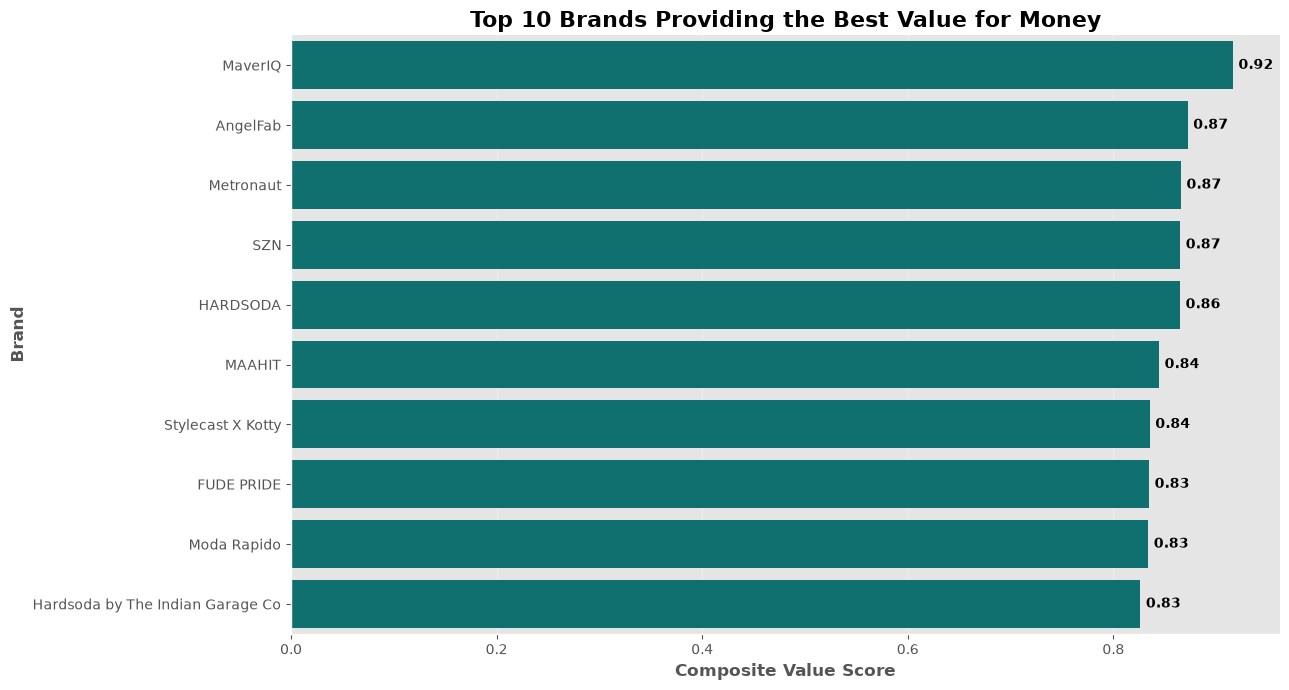

In [8]:
top_value = brand_value.head(10).reset_index()

plt.figure(figsize=(13, 7))

ax = sns.barplot(
    data=top_value,
    x="Value_Score",
    y="brand_name",
    color="teal",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Brands Providing the Best Value for Money",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Composite Value Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Brand",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_023.png", dpi=120, bbox_inches="tight")
plt.show()

 ### Observation

The chart highlights the top ten brands with the highest composite Value Scores.

MarvelQ achieved the highest overall score, followed closely by AngelFab, Metronaut, SZN, and HARDSODA. These brands consistently combine competitive pricing, attractive discounts, and positive customer ratings, making them strong value-for-money options.

The relatively small difference in scores among the top-ranked brands indicates that several brands follow similar pricing and promotional strategies while maintaining good customer satisfaction.

### Business Insight

The highest-ranked brands do not rely on a single factor such as low prices or high discounts. Instead, they achieve a balanced combination of affordability, promotional offers, and customer satisfaction.

This suggests that customers perceive greater value when multiple aspects of a product align rather than when only one metric performs well.

### Recommendation

Myntra should prioritize these high-value brands in product recommendations, promotional campaigns, and featured collections.

The pricing and discount strategies adopted by these brands can also serve as benchmarks for improving the performance of lower-ranked brands and increasing overall customer satisfaction.

### Conclusion

The composite Value Score provides a comprehensive measure of brand performance by integrating customer ratings, discount percentages, and price competitiveness into a single metric.

This analysis enables Myntra to identify brands that consistently deliver strong value for money and supports informed business decisions related to pricing, promotions, merchandising, and customer engagement.

# Business Question 2

## Which Brands Have the Strongest Customer Engagement?

### Business Objective

Customer engagement is an important indicator of a brand's popularity and market presence.

This analysis evaluates customer engagement by examining both the total number of ratings received by each brand and the average number of ratings generated per product.

Considering both metrics provides a more balanced understanding of customer interest and brand performance.

### Why is this Analysis Important?

Understanding customer engagement helps Myntra:

- Identify highly popular brands.
- Measure customer interest beyond product availability.
- Improve recommendation systems.
- Support inventory and marketing decisions.
- Prioritize brands with consistently strong customer interaction.

### Step 1 — Calculate Brand Engagement Metrics

Calculate the total number of customer ratings, total products, and average customer rating for each brand.

In [9]:
brand_engagement = (
    df.groupby("brand_name")
      .agg(
          Total_Ratings=("number_of_ratings","sum"),
          Product_Count=("brand_name","count"),
          Average_Rating=("ratings","mean")
      )
)

brand_engagement = (
    brand_engagement[
        brand_engagement["Product_Count"] >= 20
    ]
    .copy()
)

brand_engagement.head()

,Total_Ratings,Product_Count,Average_Rating
brand_name,,,
AD By Arvind,5202.0,108,3.978704
AMERICAN EAGLE OUTFITTERS,26222.0,243,4.140741
AVVA,1111.0,24,4.041667
AWACK,11799.0,149,4.055705
Aeropostale,3750.0,126,4.117460


### Observation

The table summarizes customer engagement for each brand by calculating the total number of customer ratings, total listed products, and average customer rating.

Only brands with at least 20 listed products have been retained to ensure reliable comparisons. These metrics provide the foundation for identifying brands with strong customer engagement and consistent market presence.

### Step 2 — Identify Brands with the Highest Customer Engagement

Rank brands according to the total number of customer ratings received.

In [10]:
top_engagement = (
    brand_engagement
    .sort_values(
        by="Total_Ratings",
        ascending=False
    )
    .head(10)
)

top_engagement

,Total_Ratings,Product_Count,Average_Rating
brand_name,,,
Roadster,531537.0,1794,3.869900
United Colors of Benetton,335797.0,2982,4.030248
Flying Machine,274996.0,2573,3.981656
HIGHLANDER,273136.0,285,3.830877
WROGN,148318.0,1100,4.003182
Levis,105384.0,563,4.222558
The Indian Garage Co,94793.0,372,3.946505
Urbano Fashion,80448.0,274,3.886861
Mast & Harbour,76187.0,558,3.777599


### Observation

The ranked table identifies the ten brands receiving the highest total number of customer ratings.

Roadster ranks first with the highest customer engagement, followed by United Colors of Benetton and Flying Machine. These brands generate substantial customer interaction, indicating strong popularity and high product visibility on the Myntra platform.

### Step 3 — Visualize Total Customer Engagement

Display the top ten brands based on the total number of customer ratings.

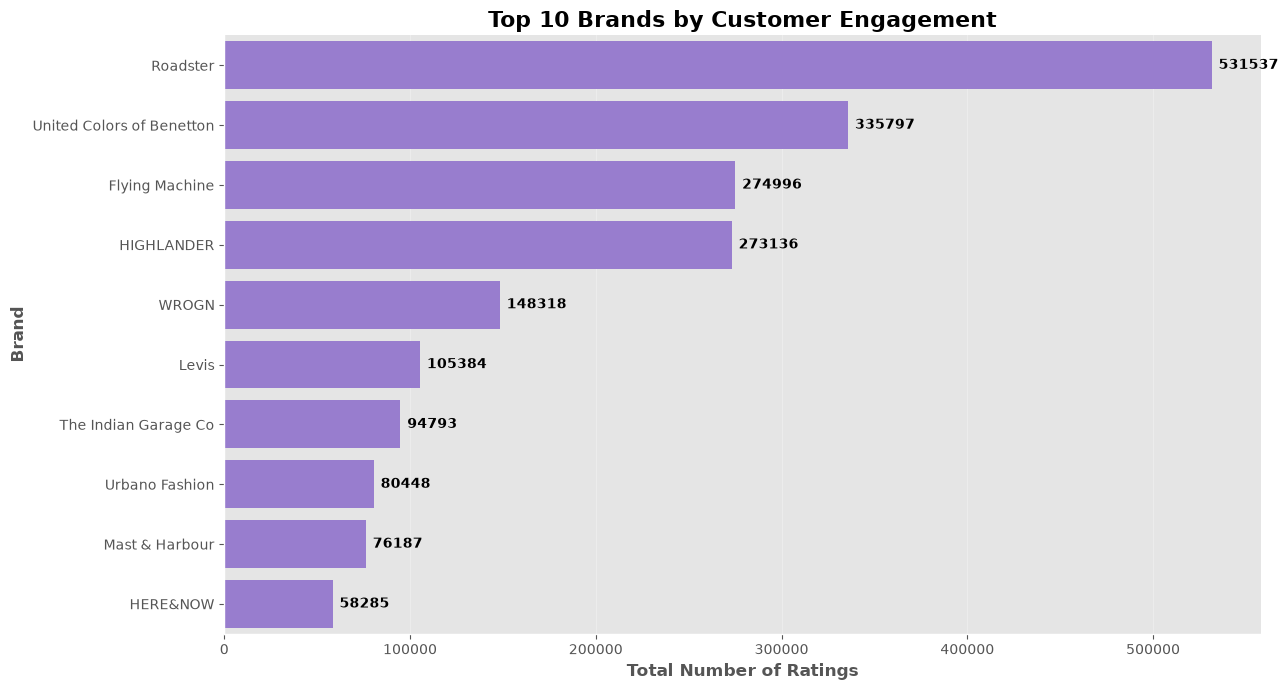

In [11]:
plt.figure(figsize=(13,7))

ax = sns.barplot(
    data=top_engagement.reset_index(),
    x="Total_Ratings",
    y="brand_name",
    color="mediumpurple",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Brands by Customer Engagement",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Total Number of Ratings",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Brand",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_038.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation

The bar chart provides a clear comparison of customer engagement across the top-performing brands.

Roadster significantly outperforms other brands in total customer ratings, while United Colors of Benetton and Flying Machine also demonstrate strong engagement. The noticeable gap between the leading brands and the remaining brands suggests differences in market reach, customer preference, and overall product visibility.

### Step 4 — Calculate Engagement per Product

Calculate the average number of customer ratings generated by each product within a brand.

This metric measures engagement efficiency by considering the size of the product catalog.

In [12]:
brand_engagement["Ratings_Per_Product"] = (
    brand_engagement["Total_Ratings"] /
    brand_engagement["Product_Count"]
).round(2)

brand_engagement.head()

,Total_Ratings,Product_Count,Average_Rating,Ratings_Per_Product
brand_name,,,,
AD By Arvind,5202.0,108,3.978704,48.17
AMERICAN EAGLE OUTFITTERS,26222.0,243,4.140741,107.91
AVVA,1111.0,24,4.041667,46.29
AWACK,11799.0,149,4.055705,79.19
Aeropostale,3750.0,126,4.117460,29.76


### Observation

Ratings per product provide a normalized measure of customer engagement by accounting for differences in catalog size.

Unlike total ratings, this metric evaluates how much customer interaction each product receives on average, allowing a fair comparison between brands with different numbers of listed products.

### Step 5 — Identify Brands with the Highest Engagement per Product

Rank brands according to the average number of ratings generated by each listed product.

In [13]:
top_efficiency = (
    brand_engagement
    .sort_values(
        by="Ratings_Per_Product",
        ascending=False
    )
    .head(10)
)

top_efficiency

,Total_Ratings,Product_Count,Average_Rating,Ratings_Per_Product
brand_name,,,,
HIGHLANDER,273136.0,285,3.830877,958.37
Roadster,531537.0,1794,3.869900,296.29
Urbano Fashion,80448.0,274,3.886861,293.61
The Indian Garage Co,94793.0,372,3.946505,254.82
Bene Kleed,36502.0,159,3.861006,229.57
Routeen,7148.0,37,3.627027,193.19
Levis,105384.0,563,4.222558,187.18
Style Quotient,3644.0,21,4.047619,173.52
Kotty,14787.0,104,3.760577,142.18


### Observation

The ranked table highlights brands that generate the highest customer engagement for each listed product.

HIGHLANDER records the highest engagement efficiency with approximately 958 ratings per product, followed by Roadster and Urbano Fashion. These brands demonstrate exceptional customer interest relative to the size of their product catalog.

### Step 6 — Visualize Engagement Efficiency

Display the top ten brands based on the average number of customer ratings per product.

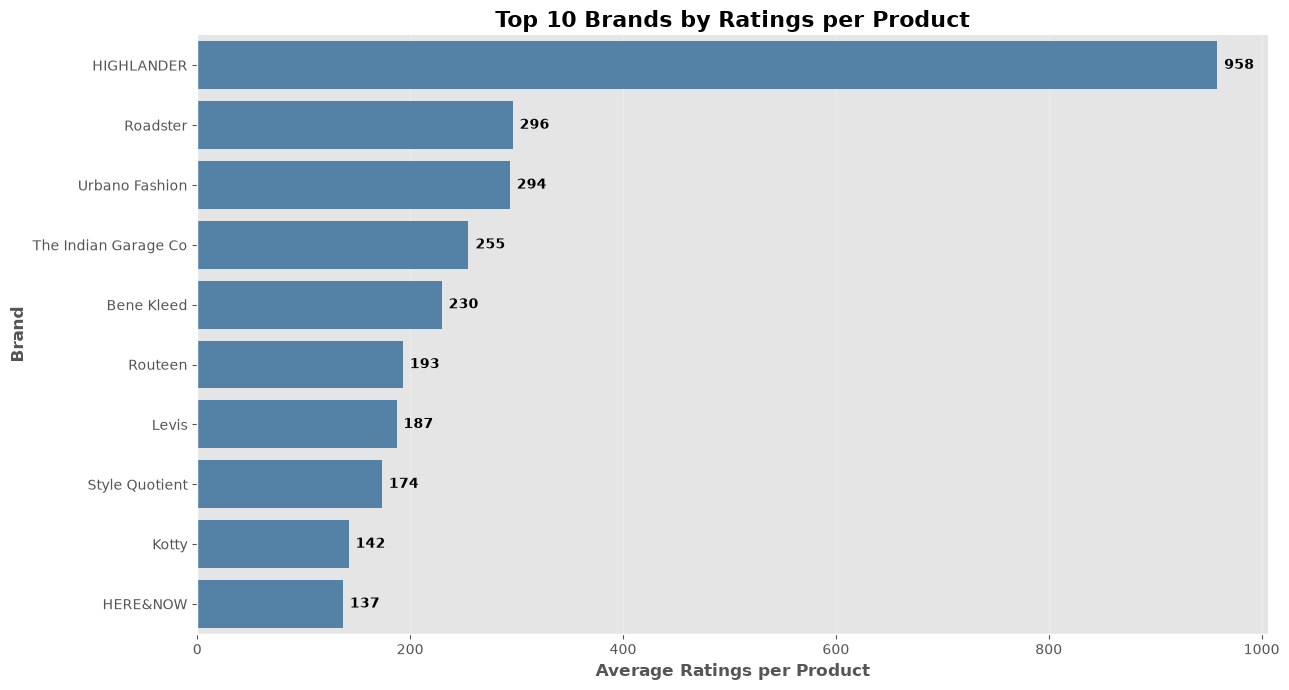

In [14]:
plt.figure(figsize=(13,7))

ax = sns.barplot(
    data=top_efficiency.reset_index(),
    x="Ratings_Per_Product",
    y="brand_name",
    color="steelblue",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Brands by Ratings per Product",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Average Ratings per Product",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Brand",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_047.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation

The visualization compares brands based on the average number of customer ratings received per product.

HIGHLANDER clearly leads in engagement efficiency, while Roadster, Urbano Fashion, and The Indian Garage Co also achieve strong performance. This indicates that these brands consistently attract customer attention across their product offerings rather than relying solely on a large catalog.

### Business Insight

Total customer ratings measure overall brand popularity, whereas ratings per product measure engagement efficiency.

Brands such as Roadster dominate overall engagement because of their extensive product catalog, while HIGHLANDER demonstrates exceptional engagement efficiency despite offering fewer products. Evaluating both metrics together provides a more comprehensive understanding of customer behavior and brand performance.

### Recommendation

Myntra should continue promoting brands with high total engagement to maintain customer traffic and sales.

Additionally, brands with high engagement efficiency, such as HIGHLANDER and Urbano Fashion, should receive greater promotional support, as they consistently generate strong customer interest for each product and have the potential to increase sales with expanded product offerings.

### Conclusion

Customer engagement analysis reveals both the most popular brands and the brands that generate the highest customer interaction per product.

By combining total customer ratings with ratings per product, Myntra gains a balanced view of brand performance that supports better marketing, merchandising, inventory planning, and product recommendation strategies.

# Business Question 3

## Which Brands Rely Most on Promotional Discounts?

### Business Objective

Promotional discounts play a significant role in influencing customer purchasing decisions and improving product visibility.

This analysis identifies brands that rely most heavily on discounts and examines whether their pricing strategy focuses on frequent promotional offers.

### Why is this Analysis Important?

Understanding discount strategies helps Myntra:

- Identify brands using aggressive promotional pricing.
- Compare pricing strategies across brands.
- Support campaign planning and seasonal sales.
- Evaluate whether brands compete through discounts or perceived product value.

### Step 1 — Calculate Brand Discount Metrics

Calculate the average discount percentage and total number of listed products for each brand.

Brands with fewer than 20 products are excluded to ensure reliable comparisons.

In [15]:
brand_discount = (
    df.groupby("brand_name")
      .agg(
          Average_Discount=("discount_percent", "mean"),
          Product_Count=("brand_name", "count"),
          Average_Rating=("ratings", "mean"),
          Average_Price=("price", "mean")
      )
)

brand_discount = (
    brand_discount[
        brand_discount["Product_Count"] >= 20
    ]
    .copy()
)

brand_discount.head()

,Average_Discount,Product_Count,Average_Rating,Average_Price
brand_name,,,,
AD By Arvind,0.373056,108,3.978704,1830.851852
AMERICAN EAGLE OUTFITTERS,0.355597,243,4.140741,3008.395062
AVVA,0.483333,24,4.041667,2839.000000
AWACK,0.269396,149,4.055705,2190.812081
Aeropostale,0.592460,126,4.117460,1374.857143


### Observation

The table summarizes each brand's average discount percentage, total number of listed products, average customer rating, and average selling price.

Only brands with at least 20 products have been included in the analysis to ensure reliable comparisons. These metrics provide a comprehensive view of each brand's pricing and promotional strategy.

### Step 2 — Identify Brands Offering the Highest Average Discounts

Rank brands according to their average discount percentage.

In [16]:
top_discount_brands = (
    brand_discount
    .sort_values(
        by="Average_Discount",
        ascending=False
    )
    .head(10)
)

top_discount_brands

,Average_Discount,Product_Count,Average_Rating,Average_Price
brand_name,,,,
AngelFab,0.790000,20,3.810000,629.000000
MAAHIT,0.769730,37,3.800000,689.162162
FUDE PRIDE,0.761515,33,3.718182,685.818182
Metronaut,0.750000,20,3.675000,574.000000
HARDSODA,0.728000,25,4.328000,734.920000
TCI,0.725568,88,4.002273,871.625000
Playfeel,0.723571,42,3.802381,698.642857
RJ Denim,0.717647,51,3.994118,980.000000
HJ HASASI,0.715124,121,3.956198,1034.727273


### Observation

The ranked table identifies the brands offering the highest average discounts across their product collections.

AngelFab offers the highest average discount, followed by MAAHIT, FUDE PRIDE, Metronaut, and HARDSODA. These brands appear to rely heavily on promotional pricing to attract customers and remain competitive in the market.

### Step 3 — Visualize Brand Discount Strategy

Display the ten brands with the highest average discount percentages.

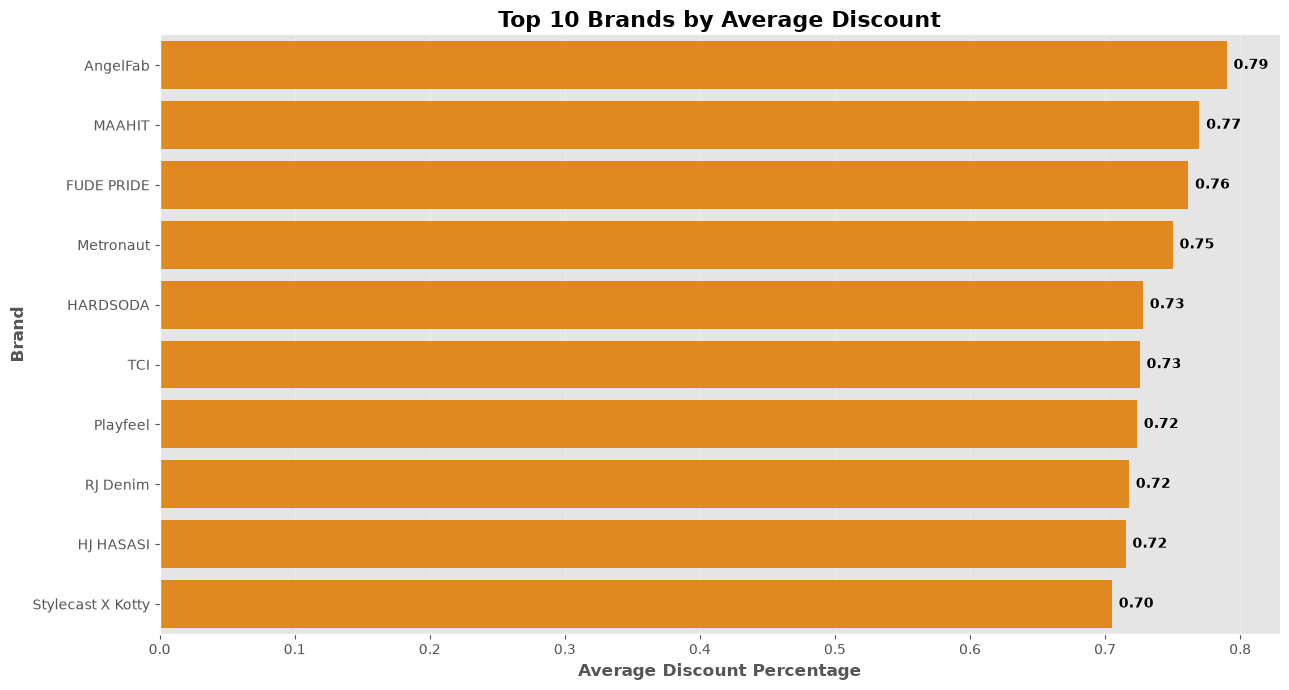

In [17]:
plt.figure(figsize=(13,7))

ax = sns.barplot(
    data=top_discount_brands.reset_index(),
    x="Average_Discount",
    y="brand_name",
    color="darkorange",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=5,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Brands by Average Discount",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Average Discount Percentage",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Brand",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_062.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation

The visualization compares the average discount percentages offered by the top ten brands.

AngelFab provides the highest average discount of approximately 79%, while the remaining brands also maintain discounts above 70%. The relatively small variation among these brands suggests that aggressive discounting is a common pricing strategy within this group.

### Step 4 — Identify Products with the Highest Discounts

Display the products receiving the highest discount percentages in the dataset.

In [18]:
top_discount_products = (
    df[
        [
            "brand_name",
            "pants_description",
            "price",
            "MRP",
            "discount_percent",
            "ratings"
        ]
    ]
    .copy()
)

top_discount_products["Discount (%)"] = (
    top_discount_products["discount_percent"] * 100
).round(0)

top_discount_products = (
    top_discount_products
    .sort_values(
        by="Discount (%)",
        ascending=False
    )
    .head(10)
)

top_discount_products

,brand_name,pants_description,price,MRP,discount_percent,ratings,Discount (%)
8217,Snitch,Men Mid-Rise Jeans,2499.0,2599.0,1.00,4.3,100.0
20960,max,Men Regular Fit Jeans,599.0,699.0,1.00,3.5,100.0
8215,The Souled Store,Men Straight Fit Jeans,2499.0,2599.0,1.00,4.3,100.0
12863,Roadster,Men Skinny Fit Jeans,2699.0,2799.0,1.00,3.4,100.0
8216,United Colors of Benetton,Men Slim Fit Mid-Rise Jeans,2499.0,2599.0,1.00,4.3,100.0
12862,The Souled Store,Men Relaxed Fit Jeans,2699.0,2799.0,1.00,3.4,100.0
12207,The Souled Store,Men Slim Fit Jeans,2199.0,2299.0,1.00,4.3,100.0
19301,max,Men Mid-Rise Stretchable Jeans,599.0,699.0,1.00,4.0,100.0
23858,Roadster,Men Relaxed Fit Jeans,539.0,3599.0,0.85,4.5,85.0
20946,United Colors of Benetton,Men Slim Fit Mid-Rise Jeans,479.0,3199.0,0.85,4.0,85.0


### Observation

The table highlights the products receiving the largest discounts in the dataset.

Several products receive discounts of up to 100%, while a few others are discounted by 85%. These products represent the most aggressively promoted items and demonstrate how individual products are used to attract customer attention during promotional campaigns.

### Step 5 — Visualize Highly Discounted Products

Create a visual comparison of the products receiving the largest discount percentages.

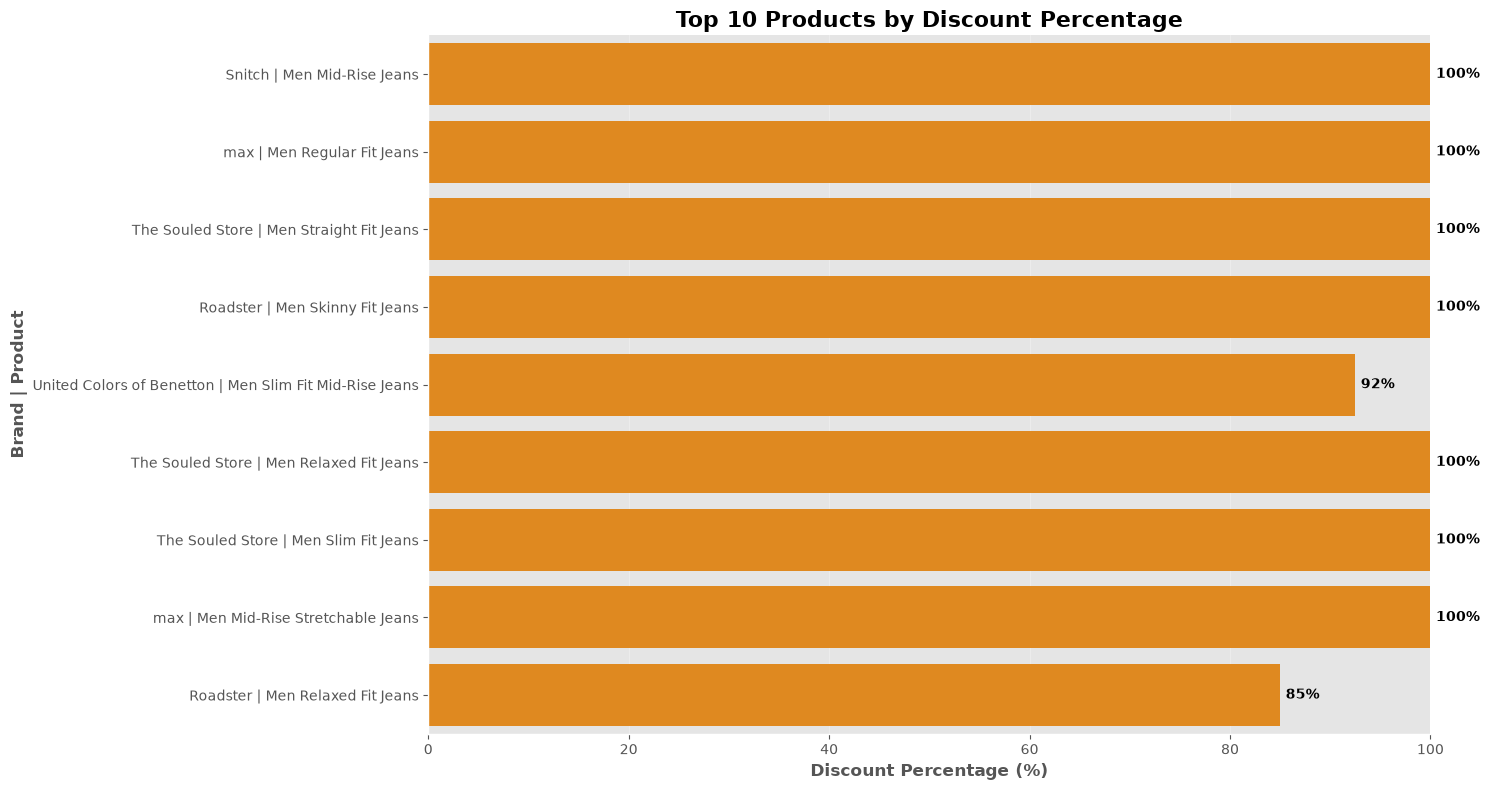

In [19]:
top_discount_products["Product_Label"] = (
    top_discount_products["brand_name"]
    + " | "
    + top_discount_products["pants_description"]
)

plt.figure(figsize=(15,8))

ax = sns.barplot(
    data=top_discount_products,
    x="Discount (%)",
    y="Product_Label",
    color="darkorange",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.0f%%",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Products by Discount Percentage",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Discount Percentage (%)",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Brand | Product",
    fontsize=12,
    fontweight="bold"
)

plt.xlim(0,100)

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_068.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation

The bar chart provides a visual comparison of the products with the highest discount percentages.

Most of the selected products receive the maximum recorded discount of 100%, while a small number of products are discounted by approximately 85–92%. This indicates that some products are used as promotional highlights to increase customer interest and drive sales.

### Business Insight

The analysis shows that some brands consistently rely on high average discounts as part of their pricing strategy, while a small number of individual products receive extremely large promotional discounts.

Although high discounts may increase product visibility and short-term sales, they should be balanced carefully to maintain profitability and preserve brand value over the long term.

### Recommendation

Myntra should continue using promotional discounts strategically rather than applying large discounts across all products.

Brands offering consistently high discounts should be monitored to ensure that promotional campaigns remain profitable. Products receiving exceptionally large discounts should be evaluated to determine whether these offers successfully increase customer engagement and sales.

### Conclusion

The analysis demonstrates that promotional pricing strategies vary across brands and products.

Identifying brands with consistently high average discounts, along with products receiving the largest promotional offers, provides valuable insights for optimizing pricing strategies, planning future campaigns, and improving overall business performance.

### Note

A few products in the dataset show discount percentages of 100%, which is uncommon in real-world retail scenarios. These values may represent promotional anomalies or data inconsistencies and should be interpreted with caution when evaluating discount strategies.

# Business Question 4

## Which Price Segment Performs Best?

### Business Objective

Products are offered across multiple price ranges, and customer preferences may differ between these segments.

This analysis evaluates the performance of different price segments by comparing product availability, customer ratings, and customer engagement.

The objective is to identify which price range delivers the strongest overall business performance.

### Why is this Analysis Important?

Understanding the performance of different price segments helps Myntra:

- Identify the most successful pricing range.
- Improve inventory planning.
- Optimize pricing strategies.
- Target promotional campaigns more effectively.
- Understand customer purchasing behavior across different price levels.

### Step 1 — Create Price Categories

Group products into predefined price segments to simplify comparison across different pricing levels.

In [20]:
price_bins = [0, 500, 1000, 2000, 5000, float("inf")]

price_labels = [
    "₹0–500",
    "₹501–1000",
    "₹1001–2000",
    "₹2001–5000",
    "₹5000+"
]

df["Price_Category"] = pd.cut(
    df["price"],
    bins=price_bins,
    labels=price_labels,
    include_lowest=True
)

df["Price_Category"].value_counts().sort_index()

Price_Category
₹0–500          549
₹501–1000      7829
₹1001–2000    16531
₹2001–5000     5996
₹5000+          622
Name: count, dtype: int64

### Observation

Products have been grouped into five price categories ranging from budget to premium.

The majority of products fall within the ₹1001–2000 price range, followed by ₹501–1000 and ₹2001–5000. In contrast, very few products are available in the ₹0–500 and ₹5000+ categories, indicating that Myntra's men's jeans collection is primarily concentrated in the mid-price segment.

### Step 2 — Analyze Product Distribution

Calculate the number of products available in each price category.

In [21]:
price_distribution = (
    df["Price_Category"]
    .value_counts()
    .sort_index()
)

price_distribution

Price_Category
₹0–500          549
₹501–1000      7829
₹1001–2000    16531
₹2001–5000     5996
₹5000+          622
Name: count, dtype: int64

### Observation

The product distribution confirms that the ₹1001–2000 price category contains the largest number of products (16,531), accounting for more than half of the dataset.

The ₹501–1000 and ₹2001–5000 categories also contain a substantial number of products, while the lowest and highest price segments have comparatively limited product availability.

### Step 3 — Visualize Product Distribution

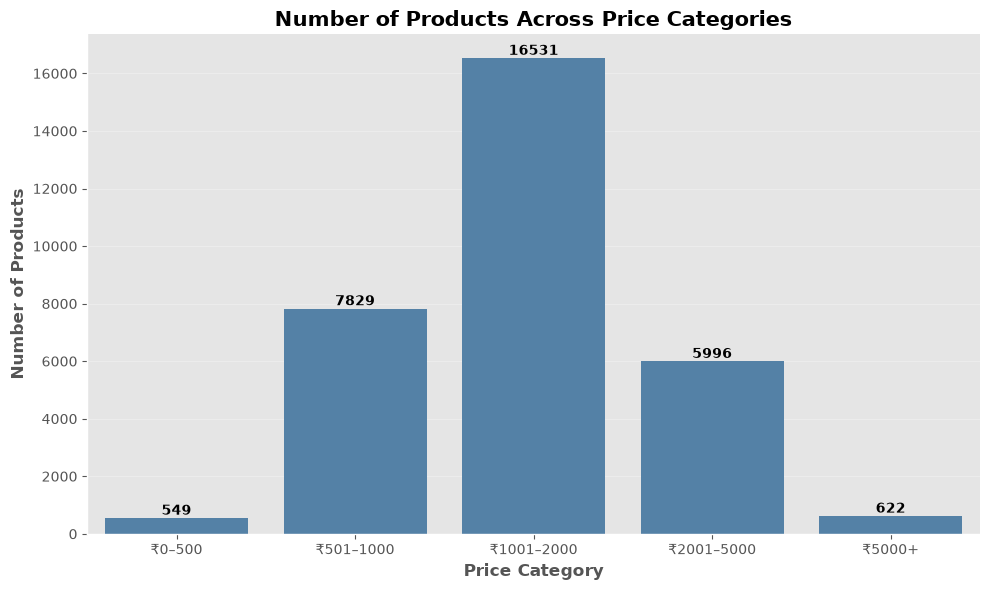

In [22]:
plt.figure(figsize=(10,6))

ax = sns.countplot(
    data=df,
    x="Price_Category",
    color="steelblue"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Number of Products Across Price Categories",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Price Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Products",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="y", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_084.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation

The visualization clearly illustrates the distribution of products across different price categories.

The ₹1001–2000 segment dominates the product catalog, suggesting that Myntra primarily targets customers seeking mid-range products. Premium (₹5000+) and budget (₹0–500) products represent only a small portion of the available inventory.

### Step 4 — Compare Customer Ratings

Evaluate how customer ratings vary across different price segments using a box plot.

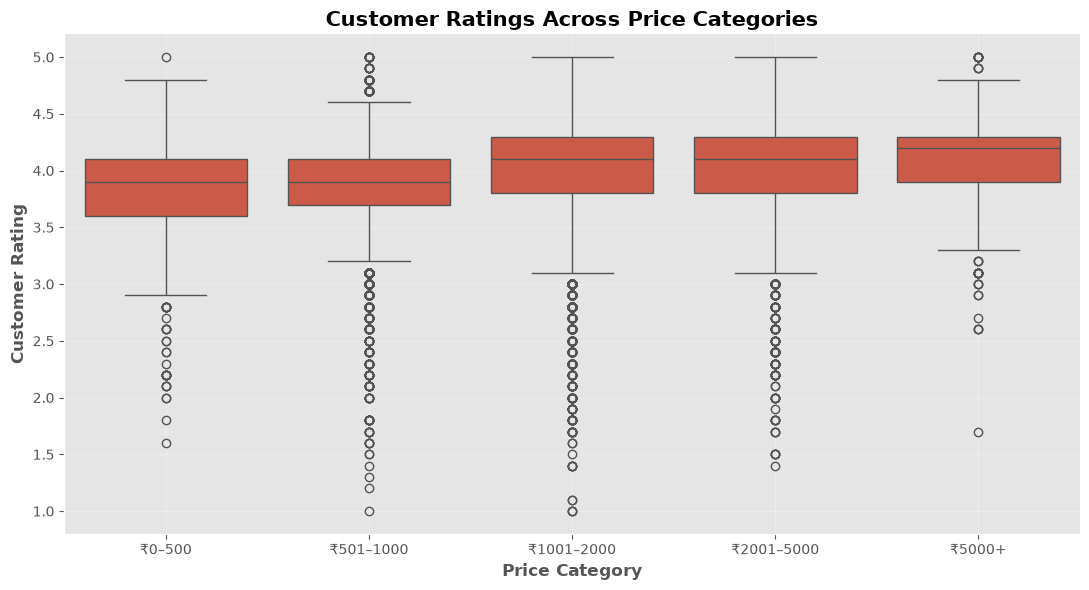

In [23]:
plt.figure(figsize=(11,6))

sns.boxplot(
    data=df,
    x="Price_Category",
    y="ratings"
)

plt.title(
    "Customer Ratings Across Price Categories",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Price Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Customer Rating",
    fontsize=12,
    fontweight="bold"
)

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_087.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation

The box plot compares customer ratings across different price categories.

Products in the ₹2001–5000 and ₹5000+ categories generally receive slightly higher median ratings than lower-priced products. However, the overlap between the distributions indicates that customer satisfaction remains relatively consistent across all price segments.

Although premium products tend to receive marginally better ratings, higher prices do not guarantee significantly higher customer satisfaction.

### Step 5 — Compare Customer Engagement

Evaluate customer engagement across price segments using the number of customer ratings.

A logarithmic scale is applied because customer engagement varies substantially between products.

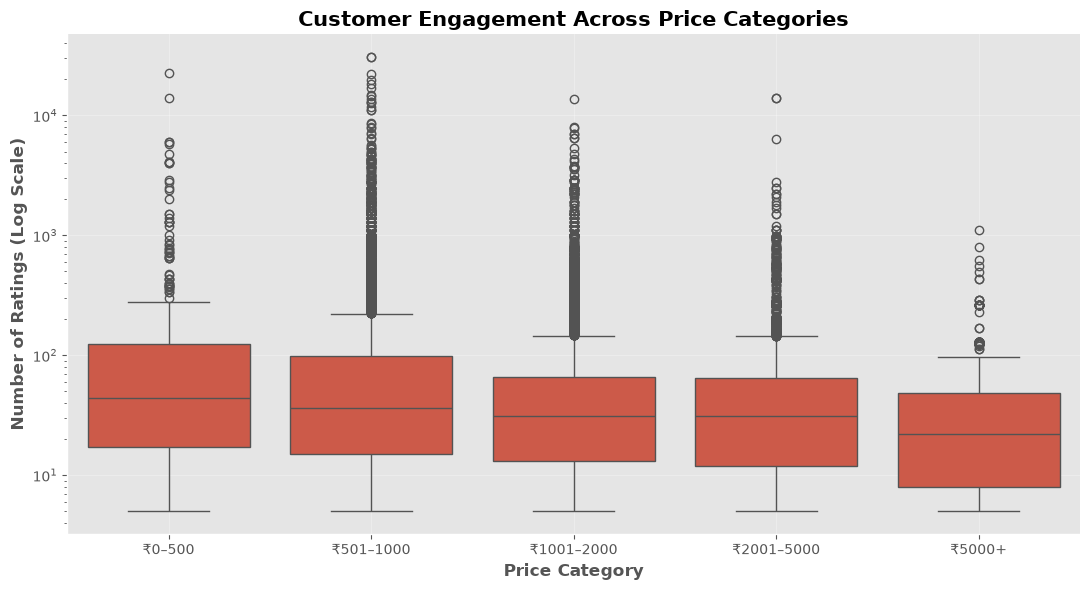

In [24]:
plt.figure(figsize=(11,6))

sns.boxplot(
    data=df,
    x="Price_Category",
    y="number_of_ratings"
)

plt.yscale("log")

plt.title(
    "Customer Engagement Across Price Categories",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Price Category",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Number of Ratings (Log Scale)",
    fontsize=12,
    fontweight="bold"
)

plt.grid(alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_090.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation

The box plot compares customer engagement across different price categories using the number of customer ratings on a logarithmic scale.

Lower and mid-priced products generally receive higher customer engagement than premium products. The ₹5000+ category shows fewer ratings overall, suggesting that premium products attract a smaller customer base despite maintaining strong customer ratings.

The logarithmic scale improves visualization by reducing the impact of extremely popular products and allowing meaningful comparison across price segments.

### Business Insight

The analysis indicates that the mid-price segment (₹1001–2000) represents the core of Myntra's men's jeans catalog, offering the largest product selection while maintaining strong customer ratings and engagement.

Premium products receive slightly higher customer ratings but generate comparatively lower customer engagement, indicating that customers purchase premium products less frequently despite being satisfied with their quality.

### Recommendation

Myntra should continue strengthening its mid-price product portfolio, as this segment demonstrates the highest product availability and consistent customer engagement.

At the same time, premium products should be marketed using targeted campaigns that emphasize quality, exclusivity, and brand value rather than relying solely on price-based promotions.

### Conclusion

The price segment analysis reveals that customer demand is concentrated in the mid-price range, while premium products achieve higher customer satisfaction but lower engagement.

These findings provide valuable guidance for pricing strategies, inventory planning, promotional campaigns, and product assortment decisions, enabling Myntra to better align its offerings with customer preferences.

# Business Question 5

## Which Brands Should Myntra Prioritize?

### Business Objective

The previous analyses evaluated brands from different perspectives, including value for money, customer engagement, promotional strategies, and pricing.

This final analysis combines these business metrics to identify the brands that consistently perform well across multiple dimensions and should therefore be prioritized by Myntra for future growth and promotional activities.

### Why is this Analysis Important?

Identifying high-performing brands helps Myntra:

- Strengthen strategic partnerships.
- Improve product recommendations.
- Allocate marketing budgets more effectively.
- Optimize inventory planning.
- Maximize customer satisfaction and long-term revenue.

### Step 1 — Combine Brand Performance Metrics

Merge the key business metrics calculated in previous analyses into a single table for final evaluation.

In [25]:
brand_summary = (
    brand_value[
        [
            "Average_Price",
            "Average_Discount",
            "Average_Rating",
            "Product_Count",
            "Value_Score"
        ]
    ]
    .merge(
        brand_engagement[
            [
                "Total_Ratings",
                "Ratings_Per_Product"
            ]
        ],
        left_index=True,
        right_index=True
    )
)

brand_summary.head()

,Average_Price,Average_Discount,Average_Rating,Product_Count,Value_Score,Total_Ratings,Ratings_Per_Product
brand_name,,,,,,,
MaverIQ,461.703704,0.644074,4.022222,108,0.916325,6555.0,60.69
AngelFab,629.000000,0.790000,3.810000,20,0.872334,453.0,22.65
Metronaut,574.000000,0.750000,3.675000,20,0.865767,903.0,45.15
SZN,486.055556,0.625278,3.707639,144,0.865082,8194.0,56.90
HARDSODA,734.920000,0.728000,4.328000,25,0.864927,733.0,29.32


### Observation

The table combines the key business metrics calculated in previous analyses, including average selling price, average discount, average customer rating, product count, value score, total customer ratings, and ratings per product.

Bringing these metrics together provides a comprehensive view of brand performance and creates a foundation for identifying brands that consistently perform well across multiple business dimensions.

### Step 2 — Normalize Business Metrics

Normalize each metric using Min-Max Scaling to ensure all variables contribute fairly to the final performance score.

In [26]:
metrics = [
    "Average_Rating",
    "Average_Discount",
    "Value_Score",
    "Ratings_Per_Product"
]

for column in metrics:
    brand_summary[column + "_Norm"] = (
        (brand_summary[column] - brand_summary[column].min()) /
        (brand_summary[column].max() - brand_summary[column].min())
    )

brand_summary.head()

,Average_Price,Average_Discount,Average_Rating,Product_Count,Value_Score,Total_Ratings,Ratings_Per_Product,Average_Rating_Norm,Average_Discount_Norm,Value_Score_Norm,Ratings_Per_Product_Norm
brand_name,,,,,,,,,,,
MaverIQ,461.703704,0.644074,4.022222,108,0.916325,6555.0,60.69,0.651734,0.791108,1.000000,0.055799
AngelFab,629.000000,0.790000,3.810000,20,0.872334,453.0,22.65,0.410023,1.000000,0.909553,0.015788
Metronaut,574.000000,0.750000,3.675000,20,0.865767,903.0,45.15,0.256264,0.942740,0.896052,0.039454
SZN,486.055556,0.625278,3.707639,144,0.865082,8194.0,56.90,0.293438,0.764201,0.894643,0.051813
HARDSODA,734.920000,0.728000,4.328000,25,0.864927,733.0,29.32,1.000000,0.911247,0.894323,0.022804


### Observation

The selected business metrics have been normalized using Min-Max Scaling, converting each variable to a common scale between 0 and 1.

Normalization ensures that no single metric dominates the final evaluation due to differences in numerical scale, allowing each performance indicator to contribute fairly to the overall Business Performance Score.

### Step 3 — Calculate Business Performance Score

Combine the normalized metrics into a single score representing overall brand performance.

In [27]:
brand_summary["Business_Performance_Score"] = (

    0.35 * brand_summary["Average_Rating_Norm"] +

    0.30 * brand_summary["Ratings_Per_Product_Norm"] +

    0.20 * brand_summary["Value_Score_Norm"] +

    0.15 * brand_summary["Average_Discount_Norm"]

)

brand_summary = brand_summary.sort_values(
    by="Business_Performance_Score",
    ascending=False
)

brand_summary.head(10)

,Average_Price,Average_Discount,Average_Rating,Product_Count,Value_Score,Total_Ratings,Ratings_Per_Product,Average_Rating_Norm,Average_Discount_Norm,Value_Score_Norm,Ratings_Per_Product_Norm,Business_Performance_Score
brand_name,,,,,,,,,,,,
HIGHLANDER,771.115789,0.660105,3.830877,285,0.784352,273136.0,958.37,0.433801,0.814057,0.728659,1.000000,0.719671
HARDSODA,734.920000,0.728000,4.328000,25,0.864927,733.0,29.32,1.000000,0.911247,0.894323,0.022804,0.672393
Sztori,1069.740741,0.610370,4.255556,27,0.754572,3563.0,131.96,0.917489,0.742861,0.667429,0.130763,0.605265
THE BEETEL HOUSE,1008.550000,0.667500,4.180000,20,0.777140,2662.0,133.10,0.831435,0.824642,0.713829,0.131962,0.597053
Hardsoda by The Indian Garage Co,781.507692,0.690769,4.184615,65,0.826301,1625.0,25.00,0.836692,0.857952,0.814908,0.018260,0.589994
MaverIQ,461.703704,0.644074,4.022222,108,0.916325,6555.0,60.69,0.651734,0.791108,1.000000,0.055799,0.563513
Style Quotient,961.285714,0.656190,4.047619,21,0.767362,3644.0,173.52,0.680660,0.808453,0.693727,0.174476,0.550587
Ducati,1467.375000,0.586250,4.229167,24,0.707886,1134.0,47.25,0.887434,0.708333,0.571441,0.041663,0.543639
The Indian Garage Co,865.408602,0.656371,3.946505,372,0.774049,94793.0,254.82,0.565496,0.808711,0.707475,0.259990,0.538722


### Observation

The Business Performance Score ranks brands by combining customer ratings, customer engagement, value for money, and promotional discount strategies into a single composite metric.

HIGHLANDER achieves the highest overall score, followed by HARDSODA and Sztori. These brands consistently perform well across multiple business indicators rather than excelling in only one area, making them the strongest overall performers in the dataset.

### Step 4 — Visualize Top Performing Brands

Display the brands with the highest overall Business Performance Scores.

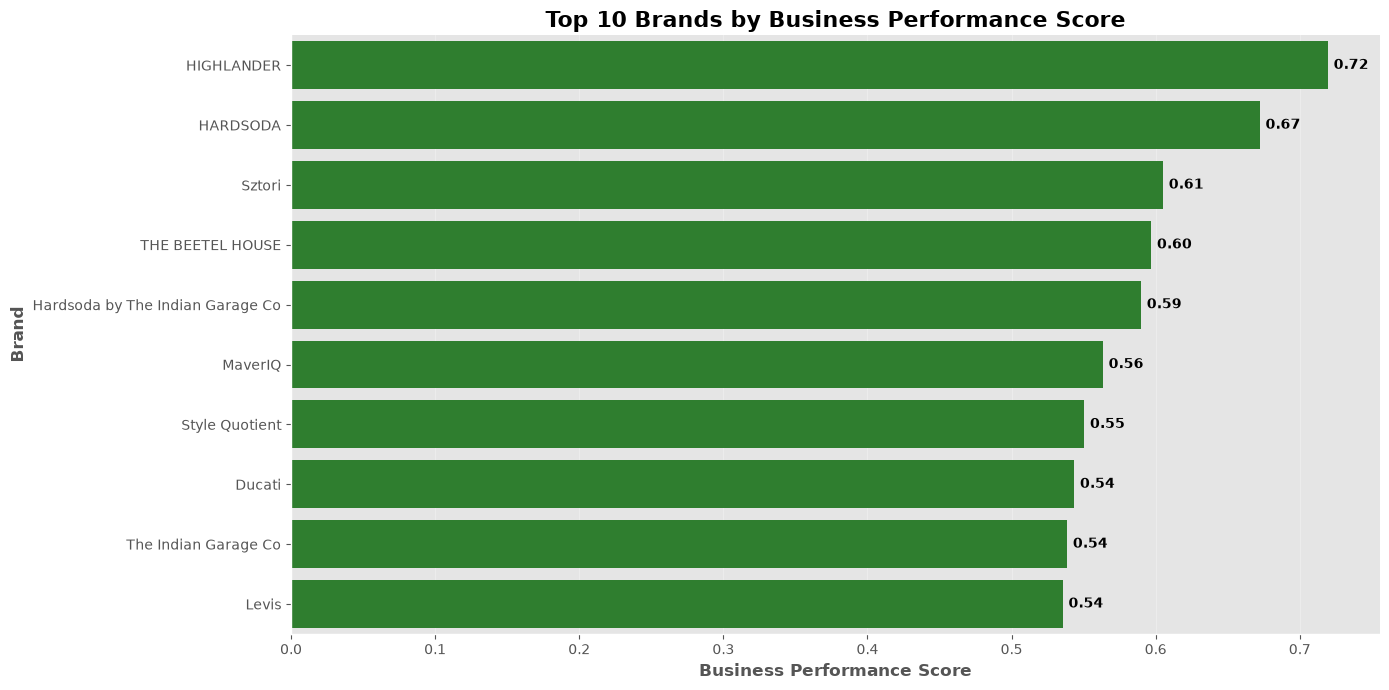

In [28]:
top_business = brand_summary.head(10).reset_index()

plt.figure(figsize=(14,7))

ax = sns.barplot(
    data=top_business,
    x="Business_Performance_Score",
    y="brand_name",
    color="forestgreen",
    errorbar=None
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=4,
        fontsize=10,
        fontweight="bold"
    )

plt.title(
    "Top 10 Brands by Business Performance Score",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Business Performance Score",
    fontsize=12,
    fontweight="bold"
)

plt.ylabel(
    "Brand",
    fontsize=12,
    fontweight="bold"
)

plt.grid(axis="x", alpha=0.3)

sns.despine()

plt.tight_layout()

plt.savefig("../images/insights_108.png", dpi=120, bbox_inches="tight")
plt.show()

### Observation

The bar chart compares the top ten brands based on their overall Business Performance Score.

HIGHLANDER leads the ranking with the highest composite score, while HARDSODA, Sztori, THE BEETEL HOUSE, and Hardsoda by The Indian Garage Co also demonstrate strong overall performance. These brands combine competitive pricing, positive customer ratings, effective promotional strategies, and customer engagement, making them valuable contributors to Myntra's product portfolio.

### Business Insight

The analysis demonstrates that overall brand success cannot be measured using a single metric. Brands that perform consistently across customer satisfaction, engagement, pricing, and promotional strategies achieve the highest Business Performance Scores.

This integrated evaluation provides a more balanced assessment of brand performance than analyzing individual metrics independently.

### Recommendation

Myntra should prioritize high-performing brands such as HIGHLANDER, HARDSODA, and Sztori for featured collections, marketing campaigns, and inventory expansion.

Brands with strong Business Performance Scores have demonstrated balanced performance across multiple business dimensions and are more likely to contribute to long-term customer satisfaction, increased sales, and sustainable business growth.

### Conclusion

By integrating pricing, customer ratings, promotional discounts, customer engagement, and value for money into a single Business Performance Score, this analysis provides a comprehensive evaluation of brand performance.

The results support data-driven decision-making by identifying the brands that consistently deliver the greatest overall business value, enabling Myntra to optimize merchandising strategies, strengthen brand partnerships, and improve long-term business performance.